# Descripción General

La tarea consiste en crear un modelo de *Machine Learning* capaz de predecir el precio medio de la vivienda por distrito en California.

Para ello, usaremos un *dataset* con datos de cada bloque censal de California del censo de 1990, con algunas modificaciones con fines educativos. Además, el dataset no está actualizado, lo que supone un sesgo que lo hace poco útil para el propósito que buscamos, pero es un buen ejemplo para aprender a trabajar con datos reales si dejamos ese hecho de lado (aunque es muy importante identificarlo).

Este [dataset se puede descargar de Kaggle](https://www.kaggle.com/camnugent/california-housing-prices), junto con detalles de su contenido, y también se pueden encontrar múltiples notebooks como este con diferentes análisis y procesamientos de los datos.

## Primer contacto con los datos

Partimos del *dataset* en un archivo csv, que cargamos en un **DataFrame** de **pandas**.

In [ ]:
import pandas as pdhousing = pd.read_csv("./data/housing.csv")

In [ ]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Observamos que el dataset tiene 10 columnas y 20.640 filas. Es un número de filas pequeño para un dataset de *Machine Learning*, pero es un buen ejemplo para aprender. Podríamos trabajar con archivos mucho más grandes, y si el dataset fuera demasiado grande, tendríamos que usar *frameworks* de **Big Data**.

In [ ]:
housing.isnull().sum() # Check el número de valores nulos

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Todas las columnas son numéricas excepto `ocean_proximity`, que es de tipo `object`. Este tipo puede contener cualquier objeto de Python, pero al haber sido leída de un CSV sabemos que es texto. Analizamos sus valores para confirmar que es una **variable categórica** con 5 posibles valores que indican la proximidad al océano.

In [ ]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Usamos el método `describe()` para obtener un resumen de estadísticas de cada columna numérica. Los valores nulos serán ignorados al calcular estas estadísticas.
También podemos usar el método `hist()` para obtener un histograma de cada columna numérica y ver su distribución.

In [ ]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


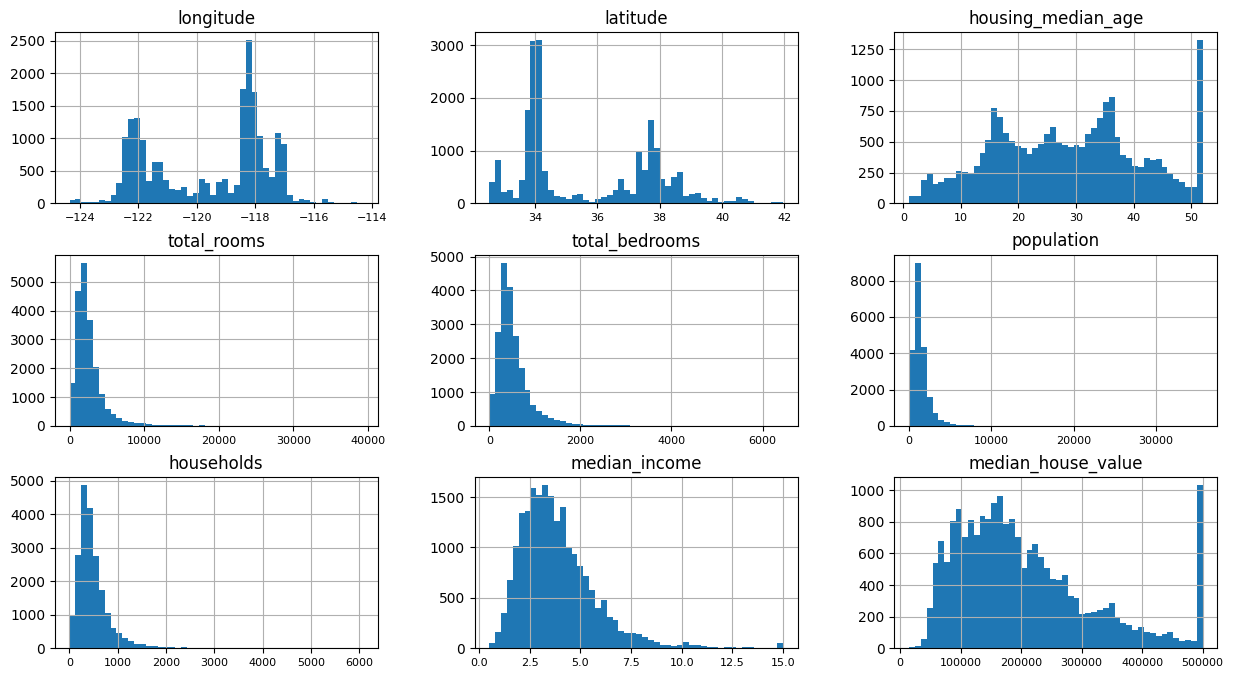

In [ ]:
housing.hist(bins=50, figsize=(15, 8),                xlabelsize=8); # Reduce the size of x-axis labels so they don't overlap

La columna `median_income` puede llamarnos la atención, ya que no está expresada en dólares. Tras consultar la [documentación](https://www.kaggle.com/datasets/camnugent/california-housing-prices), vemos que los valores de esta columna han sido escalados y limitados a un rango de 0,5 a 15,0 (de hecho, 15,0 es el valor máximo que puede tomar) y representan decenas de miles de dólares (por ejemplo, 3 equivale realmente a 30.000 USD).

Además, las columnas `housing_median_age` y `median_house_value` también han sido ***truncadas (capped)***. Esto se puede deducir de la columna larga que se ve a la derecha en sus histogramas. Los valores por encima de ese límite han sido convertidos a ese valor límite. Este proceso a veces puede ser beneficioso —por ejemplo, reduce el impacto de los valores atípicos en el [escalado](e2e043_scaling.ipynb) y la [imputación](e2e041_missing.ipynb) (véase [Valores atípicos y valores truncados](e2e020_eda.ipynb#Outliers-and-capped-values) para más detalles)— pero también podría ser un problema, especialmente en `median_house_value`, ya que representa la salida que queremos predecir. Nuestros algoritmos podrían aprender erróneamente que los precios nunca superan ese límite. En estos casos debemos consultar si esto puede ser un problema para los usos de nuestro modelo. Si necesitamos predicciones precisas incluso más allá de 500.000 USD, necesitaríamos buscar las etiquetas reales de los distritos con un `median_house_value` de 500.001. Si no podemos obtenerlas, deberemos eliminar esos distritos de los datos de entrenamiento y validación (y también de los datos de prueba, ya que no queremos evaluar nuestro modelo con ejemplos que no se usarán en la práctica).

Es habitual tener que trabajar con datos que ya han sido preprocesados; es importante entender qué criterios se han seguido y, si es posible, obtener los datos originales y preprocesarlos nosotros mismos.

También podemos observar que varios histogramas tienen colas más gruesas hacia la derecha (véase [Valores atípicos y valores truncados](e2e020_eda.ipynb#Outliers-and-capped-values)). Esto puede dificultar que algunos algoritmos de *Machine Learning* detecten patrones. Intentaremos transformar estas variables más adelante para que tengan una distribución más simétrica (véase [Distribuciones de cola pesada](e2e043_scaling.ipynb#Heavy-tailed-distributions)).

Esto también se puede observar en la relación entre la media y la mediana. Por ejemplo, la media en `total_bedrooms` es 537,87 y la mediana es 435,00. Esto nos indica que la distribución de los valores de esta variable está sesgada a la derecha, ya que la mediana es menor que la media. Esto es importante tenerlo en cuenta, ya que puede afectar a cómo gestionamos los valores faltantes.

Otra cosa que puede llamarnos la atención es la columna `ocean_proximity`, que no aparece en el resumen de estadísticas. Esto se debe a que es una **variable categórica**, no numérica. No tiene sentido calcular estadísticas sobre ella.

## Encuadramiento del problema

Tenemos por tanto el objetivo de entrenar un modelo de *Machine Learning* capaz de predecir el precio medio de la vivienda en cualquier distrito de California. Para este entrenamiento disponemos de un dataset con 20.640 filas, cada una de las cuales representa un distrito de California, y 10 columnas con información sobre cada distrito. Una de las columnas es el precio medio de la vivienda en ese distrito, que es lo que queremos predecir; es por tanto la **variable objetivo**. Las otras 9 columnas son las **variables independientes** o ***features***.

Al tener una variable objetivo continua (una **etiqueta** para cada muestra), nos encontramos ante un problema de **aprendizaje supervisado**. Además, como esta variable es un valor numérico continuo, estamos ante un problema de **regresión**.

## Selección de la medida de rendimiento

Para evaluar el rendimiento de nuestro modelo, usaremos el **Error Cuadrático Medio de la Raíz (RMSE)**, una medida de rendimiento muy habitual en problemas de regresión.

### Métricas de rendimiento vs. funciones de pérdida

Es importante distinguir entre conceptos relacionados pero distintos:

- **Métricas de rendimiento** (o métricas de evaluación): Funciones usadas para **medir** qué tan bien funciona un modelo. Se calculan sobre las predicciones frente a los valores reales tras el entrenamiento. Ejemplos: RMSE, MAE, R², accuracy, F1-score.

- **Funciones de pérdida** (o funciones de coste): Funciones que el algoritmo de aprendizaje intenta **minimizar** durante el entrenamiento. Guían el proceso de optimización y deben ser diferenciables para los métodos basados en gradiente. Ejemplos: Error Cuadrático Medio (MSE), Entropía Cruzada.

**En regresión**, la distinción suele difuminarse porque la misma función puede cumplir ambos propósitos. El MSE es a la vez una función de pérdida natural (convexa, diferenciable, fácil de optimizar) y una métrica significativa. El RMSE es simplemente $\sqrt{\text{MSE}}$, con la ventaja de que sus unidades coinciden con las de la variable objetivo (dólares en nuestro caso), lo que lo hace más interpretable.

**En clasificación**, la distinción es más clara. La entropía cruzada se usa normalmente como función de pérdida porque es suave y diferenciable, proporcionando gradientes útiles para la optimización. Sin embargo, solemos *evaluar* el modelo usando métricas como accuracy, precisión, recall o F1-score —que no son diferenciables (implican contar predicciones correctas/incorrectas discretas) y, por tanto, no pueden optimizarse directamente.

### ¿Por qué RMSE en lugar de MAE?

Tanto el RMSE como el MAE (Error Absoluto Medio) son métricas de regresión válidas, pero tienen propiedades diferentes:

| Propiedad | RMSE | MAE |
|-----------|------|-----|
| Penaliza errores grandes | Más (al cuadrado) | De forma lineal |
| Sensibilidad a valores atípicos | Mayor | Menor |
| Diferenciabilidad | Suave en todo punto | No diferenciable en 0 |
| Unidades | Iguales al objetivo | Iguales al objetivo |

Se prefiere el RMSE cuando:
- Los errores grandes son especialmente indeseables (por ejemplo, predecir una casa a 100.000 $ cuando vale 500.000 $ es mucho peor que equivocarse en 50.000 $ dos veces)
- Se quiere coherencia con la optimización basada en MSE

Se prefiere el MAE cuando:
- Se quiere robustez ante valores atípicos
- Todos los errores deben ponderarse igual independientemente de su magnitud

Para los precios de la vivienda, el RMSE es una elección razonable: infravalorar o sobrevalorar significativamente una propiedad tiene consecuencias desproporcionadas.

Para una comprensión más profunda de las métricas de regresión y sus fundamentos matemáticos, véase el [notebook de Regresión Lineal](../ia25/algorithms/linear_regression.ipynb).